# Estudo Comparativo de Modelos Preditivos: Custos Médicos

**dataset:** Medical_cost_personal  
**Disciplina:** Aprendizagem Computacional  


## 1. Configuração

Esta secção define bibliotecas, constantes globais e funções de portabilidade para localizar automaticamente o dataset `insurance.csv`.


In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
RANDOM_STATE = 42
TARGET = "charges"

FULL_FEATURES = ["age", "sex", "bmi", "children", "smoker", "region"]
REDUCED_FEATURES = ["smoker", "age", "bmi"]


def locate_dataset(filename: str = "insurance.csv") -> Path:
    """Localiza o ficheiro CSV."""
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "trabalho" / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Não foi possível localizar {filename}. Verifique a pasta data/."
    )


def load_data(path: Path) -> pd.DataFrame:
    """Carrega o dataset e valida as colunas."""
    df = pd.read_csv(path)
    expected_columns = set(FULL_FEATURES + [TARGET])
    missing_columns = expected_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Faltam colunas esperadas: {missing_columns}")
    return df


DATA_PATH = locate_dataset()
df = load_data(DATA_PATH)
print(f"Dataset localizado em: {DATA_PATH}")
display(df.head())


Dataset localizado em: c:\Users\rodri\Documents\2semestre\AC\trabalho\data\insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


## 2. Inspeção Inicial do Dataset

Antes da modelagem, confirmamos dimensão, tipos de dados e valores em falta. Embora este dataset esteja limpo, a imputação continuará no pipeline por exigência metodológica e para evitar *data leakage* em cenários futuros.


In [3]:
print(f"Dimensão do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.describe(include="all").T)
display(df.isna().sum().rename("missing_values").to_frame())


Dimensão do dataset: 1338 linhas x 7 colunas


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"1,338.0000",NaN,NaN,NaN,39.2070,14.0500,18.0000,27.0000,39.0000,51.0000,64.0000
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,"1,338.0000",NaN,NaN,NaN,30.6634,6.0982,15.9600,26.2963,30.4000,34.6938,53.1300
children,"1,338.0000",NaN,NaN,NaN,1.0949,1.2055,0.0000,0.0000,1.0000,2.0000,5.0000
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,"1,338.0000",NaN,NaN,NaN,"13,270.4223","12,110.0112","1,121.8739","4,740.2872","9,382.0330","16,639.9125","63,770.4280"


,missing_values
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## 3. Pré-processamento Anti-Leakage

Todas as transformações serão encapsuladas num `Pipeline` com `ColumnTransformer`, garantindo que imputação, `StandardScaler` e codificação categórica sejam ajustados apenas nos dados de treino de cada fold.


In [4]:
def split_features_by_type(feature_set: list[str]) -> tuple[list[str], list[str]]:
    """Separa atributos numéricos e categóricos."""
    numeric_candidates = ["age", "bmi", "children"]
    categorical_candidates = ["sex", "smoker", "region"]
    numeric_features = [feature for feature in feature_set if feature in numeric_candidates]
    categorical_features = [feature for feature in feature_set if feature in categorical_candidates]
    return numeric_features, categorical_features


def make_one_hot_encoder() -> OneHotEncoder:
    """Cria um OneHotEncoder compatível."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(
    numeric_features: list[str],
    categorical_features: list[str],
    model_type: str = "rf",
) -> Pipeline:
    """Monta o pipeline de pré-processamento e modelo."""
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )

    if model_type == "rf":
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    elif model_type == "lr":
        model = LinearRegression()
    elif model_type == "ridge":
        model = RidgeCV(alphas=np.logspace(-3, 3, 25))
    elif model_type == "lasso":
        model = LassoCV(
            alphas=np.logspace(-3, 1, 25),
            cv=5,
            random_state=RANDOM_STATE,
            max_iter=10000,
        )
    else:
        raise ValueError("model_type deve ser 'rf', 'lr', 'ridge' ou 'lasso'.")

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


## 4. Funções de Avaliação e Protocolos de Validação

Nesta secção definimos as funções reutilizáveis para cálculo de métricas, execução dos protocolos de validação e construção de tabelas resumo.


In [5]:
def compute_metrics(y_true, y_pred) -> dict:
    """Calcula MAE, RMSE e R2."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan,
    }


def get_model_label(model_type: str) -> str:
    """Converte o identificador interno do modelo."""
    mapping = {
        "rf": "Random Forest",
        "lr": "Regressão Linear",
        "ridge": "Ridge",
        "lasso": "Lasso",
    }
    return mapping[model_type]


def evaluate_resampling_strategy(
    X: pd.DataFrame,
    y: pd.Series,
    split_iterator,
    technique_name: str,
    model_type: str,
    numeric_features: list[str],
    categorical_features: list[str],
) -> tuple[pd.DataFrame, dict]:
    """Avalia uma técnica de validação."""
    split_rows = []
    pooled_truth = []
    pooled_pred = []
    base_estimator = build_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        model_type=model_type,
    )

    for iteration, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        model = clone(base_estimator)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        pooled_truth.extend(y_test.to_numpy())
        pooled_pred.extend(np.asarray(y_pred))

        row = compute_metrics(y_test, y_pred)
        row["Technique"] = technique_name
        row["Model"] = get_model_label(model_type)
        row["Iteration"] = iteration
        row["TestSize"] = len(test_idx)
        split_rows.append(row)

    split_df = pd.DataFrame(split_rows)
    pooled_metrics = compute_metrics(np.array(pooled_truth), np.array(pooled_pred))
    pooled_metrics["Technique"] = technique_name
    pooled_metrics["Model"] = get_model_label(model_type)
    pooled_metrics["n_splits"] = len(split_df)
    pooled_metrics["n_predictions"] = len(pooled_truth)

    return split_df, pooled_metrics


def evaluate_holdout(
    X: pd.DataFrame,
    y: pd.Series,
    model_type: str,
    numeric_features: list[str],
    categorical_features: list[str],
) -> tuple[pd.DataFrame, dict]:
    """Executa Hold-out 70/30."""
    train_idx, test_idx = train_test_split(
        np.arange(len(X)),
        test_size=0.30,
        random_state=RANDOM_STATE,
    )
    return evaluate_resampling_strategy(
        X=X,
        y=y,
        split_iterator=[(train_idx, test_idx)],
        technique_name="Hold-out (70/30)",
        model_type=model_type,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )


def run_validation_study(
    df: pd.DataFrame,
    feature_set: list[str],
    model_type: str,
    include_loocv: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Executa o estudo de validação para um modelo."""
    X = df[feature_set].copy()
    y = df[TARGET].copy()
    numeric_features, categorical_features = split_features_by_type(feature_set)

    strategies = [
        ("Hold-out (70/30)", None),
        ("K-Fold CV (10)", KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE).split(X, y)),
        (
            "Repeated K-Fold (10x5)",
            RepeatedKFold(n_splits=10, n_repeats=5, random_state=RANDOM_STATE).split(X, y),
        ),
    ]
    if include_loocv:
        strategies.append(("LOOCV", LeaveOneOut().split(X, y)))

    split_results = []
    pooled_results = []

    for technique_name, splitter in strategies:
        start_time = time.time()
        if technique_name == "Hold-out (70/30)":
            split_df, pooled_metrics = evaluate_holdout(
                X=X,
                y=y,
                model_type=model_type,
                numeric_features=numeric_features,
                categorical_features=categorical_features,
            )
        else:
            split_df, pooled_metrics = evaluate_resampling_strategy(
                X=X,
                y=y,
                split_iterator=splitter,
                technique_name=technique_name,
                model_type=model_type,
                numeric_features=numeric_features,
                categorical_features=categorical_features,
            )
        pooled_metrics["ExecutionTimeSeconds"] = time.time() - start_time
        split_results.append(split_df)
        pooled_results.append(pooled_metrics)
        print(
            f"{get_model_label(model_type)} | {technique_name} concluída em "
            f"{pooled_metrics['ExecutionTimeSeconds']:.2f} s"
        )

    return pd.concat(split_results, ignore_index=True), pd.DataFrame(pooled_results)


def build_summary_table(split_df: pd.DataFrame, pooled_df: pd.DataFrame) -> pd.DataFrame:
    """Resume médias, desvios padrão e métricas agregadas."""
    summary = (
        split_df.groupby(["Model", "Technique"])
        .agg(
            MAE_mean=("MAE", "mean"),
            MAE_std=("MAE", "std"),
            RMSE_mean=("RMSE", "mean"),
            RMSE_std=("RMSE", "std"),
            R2_mean=("R2", "mean"),
            R2_std=("R2", "std"),
            n_evaluations=("Iteration", "count"),
        )
        .reset_index()
    )

    summary = summary.merge(
        pooled_df[["Model", "Technique", "MAE", "RMSE", "R2", "ExecutionTimeSeconds"]],
        on=["Model", "Technique"],
        how="left",
    )

    summary = summary.rename(
        columns={
            "MAE": "MAE_pooled",
            "RMSE": "RMSE_pooled",
            "R2": "R2_pooled",
            "ExecutionTimeSeconds": "ExecutionTimeSeconds_pooled",
        }
    )

    return summary.sort_values(["Model", "MAE_pooled"]).reset_index(drop=True)


## 5. Protocolos de Validação: Regressão Linear

A Regressão Linear será avaliada com Hold-out, K-Fold, Repeated K-Fold e LOOCV. O LOOCV é mantido apenas como prova de conceito, pois é computacionalmente caro e o `R²` não é definido por fold quando o conjunto de teste tem apenas uma observação.


In [6]:
linear_split_results, linear_pooled_results = run_validation_study(
    df=df,
    feature_set=FULL_FEATURES,
    model_type="lr",
    include_loocv=True,
)

linear_summary = build_summary_table(linear_split_results, linear_pooled_results)
display(linear_summary)


Regressão Linear | Hold-out (70/30) concluída em 0.14 s
Regressão Linear | K-Fold CV (10) concluída em 0.40 s
Regressão Linear | Repeated K-Fold (10x5) concluída em 1.98 s
Regressão Linear | LOOCV concluída em 47.16 s


,Model,Technique,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,n_evaluations,MAE_pooled,RMSE_pooled,R2_pooled,ExecutionTimeSeconds_pooled
0,Regressão Linear,Hold-out (70/30),"4,145.4506",NaN,"5,812.1003",NaN,0.7696,NaN,1,"4,145.4506","5,812.1003",0.7696,0.1365
1,Regressão Linear,LOOCV,"4,202.0902","4,406.0458","4,202.0902","4,406.0458",NaN,NaN,1338,"4,202.0902","6,087.3880",0.7471,47.1571
2,Regressão Linear,Repeated K-Fold (10x5),"4,203.9652",417.2952,"6,055.7441",641.4425,0.7420,0.0549,50,"4,203.7421","6,088.7246",0.7470,1.9844
3,Regressão Linear,K-Fold CV (10),"4,204.6377",280.1639,"6,070.3504",436.0309,0.7390,0.0621,10,"4,204.8275","6,084.1872",0.7474,0.3975


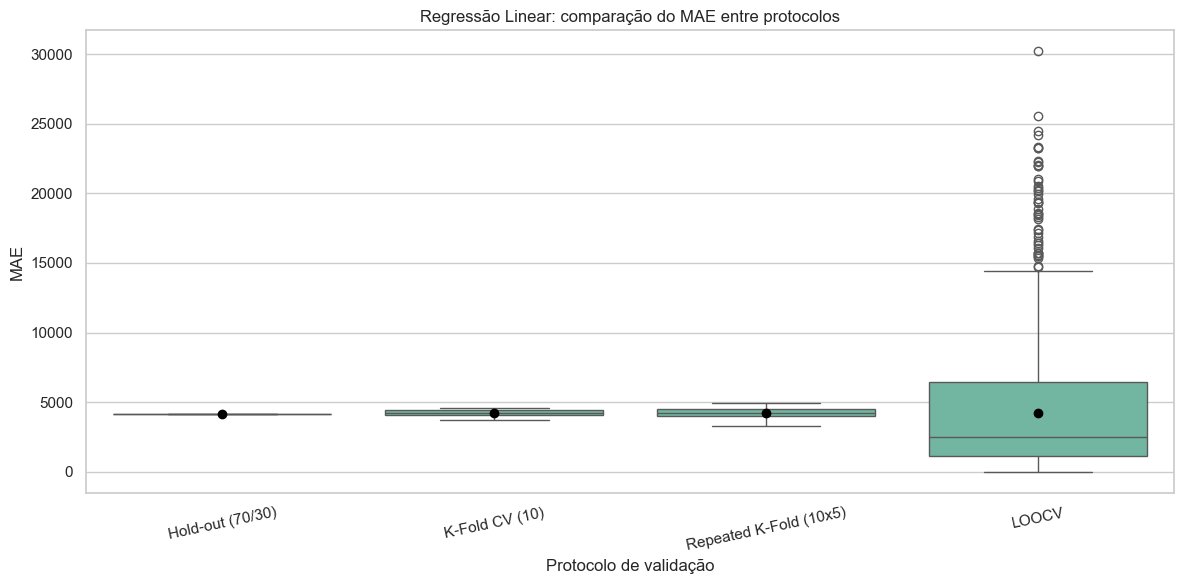

In [7]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=linear_split_results,
    x="Technique",
    y="MAE",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 6,
    },
)
ax.set_title("Regressão Linear: comparação do MAE entre protocolos")
ax.set_xlabel("Protocolo de validação")
ax.set_ylabel("MAE")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()


## 6. Protocolos de Validação: Random Forest

O Random Forest será comparado nos protocolos Hold-out, K-Fold e Repeated K-Fold. O LOOCV não é incluído aqui devido ao elevado custo computacional para um modelo baseado em árvores.


In [8]:
rf_split_results, rf_pooled_results = run_validation_study(
    df=df,
    feature_set=FULL_FEATURES,
    model_type="rf",
    include_loocv=False,
)

rf_summary = build_summary_table(rf_split_results, rf_pooled_results)
display(rf_summary)


Random Forest | Hold-out (70/30) concluída em 0.79 s
Random Forest | K-Fold CV (10) concluída em 9.41 s
Random Forest | Repeated K-Fold (10x5) concluída em 45.26 s


,Model,Technique,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,n_evaluations,MAE_pooled,RMSE_pooled,R2_pooled,ExecutionTimeSeconds_pooled
0,Random Forest,Hold-out (70/30),"2,566.6153",NaN,"4,610.8662",NaN,0.8550,NaN,1,"2,566.6153","4,610.8662",0.8550,0.7852
1,Random Forest,Repeated K-Fold (10x5),"2,654.0227",350.3578,"4,784.3296",703.8731,0.8363,0.0502,50,"2,653.9076","4,834.6341",0.8405,45.2584
2,Random Forest,K-Fold CV (10),"2,693.0911",170.1834,"4,878.2450",460.1210,0.8316,0.0400,10,"2,692.9534","4,897.2444",0.8363,9.4103


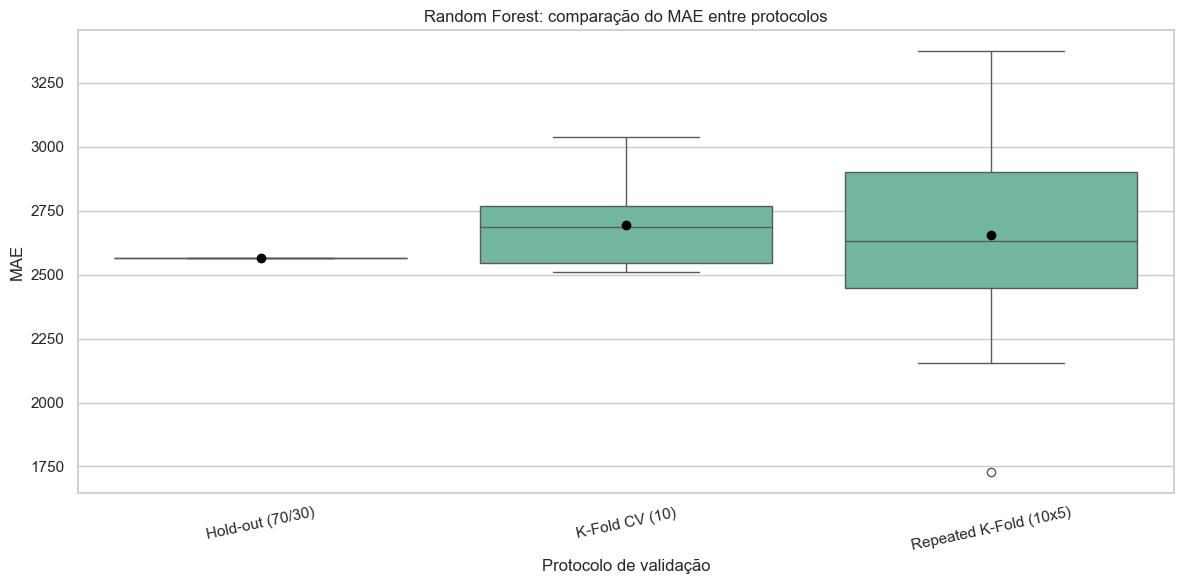

In [9]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=rf_split_results,
    x="Technique",
    y="MAE",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 6,
    },
)
ax.set_title("Random Forest: comparação do MAE entre protocolos")
ax.set_xlabel("Protocolo de validação")
ax.set_ylabel("MAE")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()


## 7. Comparação RF vs. Regressão Linear e Estabilidade no Repeated K-Fold

Seguindo a motivação metodológica de Tougui et al., vamos comparar não apenas o desempenho médio, mas também a variabilidade das métricas sob mudanças de amostragem. Para isso, observamos especialmente os desvios padrão do `MAE` e do `RMSE` no `Repeated K-Fold (10x5)`.


In [10]:
protocol_summary = pd.concat([linear_summary, rf_summary], ignore_index=True)
display(protocol_summary)

stability_comparison = protocol_summary.loc[
    protocol_summary["Technique"] == "Repeated K-Fold (10x5)",
    ["Model", "Technique", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std", "R2_pooled"],
].reset_index(drop=True)

display(stability_comparison)


,Model,Technique,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,n_evaluations,MAE_pooled,RMSE_pooled,R2_pooled,ExecutionTimeSeconds_pooled
0,Regressão Linear,Hold-out (70/30),"4,145.4506",NaN,"5,812.1003",NaN,0.7696,NaN,1,"4,145.4506","5,812.1003",0.7696,0.1365
1,Regressão Linear,LOOCV,"4,202.0902","4,406.0458","4,202.0902","4,406.0458",NaN,NaN,1338,"4,202.0902","6,087.3880",0.7471,47.1571
2,Regressão Linear,Repeated K-Fold (10x5),"4,203.9652",417.2952,"6,055.7441",641.4425,0.7420,0.0549,50,"4,203.7421","6,088.7246",0.7470,1.9844
3,Regressão Linear,K-Fold CV (10),"4,204.6377",280.1639,"6,070.3504",436.0309,0.7390,0.0621,10,"4,204.8275","6,084.1872",0.7474,0.3975
4,Random Forest,Hold-out (70/30),"2,566.6153",NaN,"4,610.8662",NaN,0.8550,NaN,1,"2,566.6153","4,610.8662",0.8550,0.7852
5,Random Forest,Repeated K-Fold (10x5),"2,654.0227",350.3578,"4,784.3296",703.8731,0.8363,0.0502,50,"2,653.9076","4,834.6341",0.8405,45.2584
6,Random Forest,K-Fold CV (10),"2,693.0911",170.1834,"4,878.2450",460.1210,0.8316,0.0400,10,"2,692.9534","4,897.2444",0.8363,9.4103


,Model,Technique,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_pooled
0,Regressão Linear,Repeated K-Fold (10x5),"4,203.9652",417.2952,"6,055.7441",641.4425,0.7470
1,Random Forest,Repeated K-Fold (10x5),"2,654.0227",350.3578,"4,784.3296",703.8731,0.8405


## 8. Simplificação do modelo - tentativas 

Agora avaliamos a simplificação do espaço de atributos e o papel da regularização. Para isso, comparamos seis cenários:

- **A:** Random Forest com todas as variáveis  
- **B:** Random Forest com `smoker`, `age`, `bmi`  
- **C:** Regressão Linear com todas as variáveis  
- **D:** Regressão Linear com `smoker`, `age`, `bmi`  
- **E:** Ridge com todas as variáveis  
- **F:** Lasso com todas as variáveis  


In [11]:
def evaluate_repeated_kfold_scenario(
    df: pd.DataFrame,
    feature_set: list[str],
    scenario_name: str,
    model_type: str,
) -> tuple[pd.DataFrame, dict]:
    """Avalia um cenário no Repeated K-Fold."""
    X = df[feature_set].copy()
    y = df[TARGET].copy()
    numeric_features, categorical_features = split_features_by_type(feature_set)

    cv = RepeatedKFold(n_splits=10, n_repeats=5, random_state=RANDOM_STATE)
    base_estimator = build_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        model_type=model_type,
    )

    split_rows = []
    pooled_truth = []
    pooled_pred = []
    start_time = time.time()

    for iteration, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        model = clone(base_estimator)
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        pooled_truth.extend(y_test.to_numpy())
        pooled_pred.extend(np.asarray(y_pred))

        row = compute_metrics(y_test, y_pred)
        row["Scenario"] = scenario_name
        row["Model"] = get_model_label(model_type)
        row["Iteration"] = iteration
        split_rows.append(row)

    split_df = pd.DataFrame(split_rows)
    pooled_metrics = compute_metrics(np.array(pooled_truth), np.array(pooled_pred))
    pooled_metrics["Scenario"] = scenario_name
    pooled_metrics["Model"] = get_model_label(model_type)
    pooled_metrics["ExecutionTimeSeconds"] = time.time() - start_time

    return split_df, pooled_metrics


def run_ablation_experiment(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Executa os cenários de ablação e regularização."""
    scenarios = {
        "Cenário A (Random Forest - Todas as variáveis)": {
            "features": FULL_FEATURES,
            "model_type": "rf",
        },
        "Cenário B (Random Forest - smoker, age, bmi)": {
            "features": REDUCED_FEATURES,
            "model_type": "rf",
        },
        "Cenário C (Regressão Linear - Todas as variáveis)": {
            "features": FULL_FEATURES,
            "model_type": "lr",
        },
        "Cenário D (Regressão Linear - smoker, age, bmi)": {
            "features": REDUCED_FEATURES,
            "model_type": "lr",
        },
        "Cenário E (Ridge - Todas as variáveis)": {
            "features": FULL_FEATURES,
            "model_type": "ridge",
        },
        "Cenário F (Lasso - Todas as variáveis)": {
            "features": FULL_FEATURES,
            "model_type": "lasso",
        },
    }

    split_results = []
    pooled_results = []

    for scenario_name, config in scenarios.items():
        split_df, pooled_metrics = evaluate_repeated_kfold_scenario(
            df=df,
            feature_set=config["features"],
            scenario_name=scenario_name,
            model_type=config["model_type"],
        )
        print(
            f"{scenario_name} concluído em "
            f"{pooled_metrics['ExecutionTimeSeconds']:.2f} s"
        )
        split_results.append(split_df)
        pooled_results.append(pooled_metrics)

    return pd.concat(split_results, ignore_index=True), pd.DataFrame(pooled_results)


split_results_ablation, pooled_results_ablation = run_ablation_experiment(df)
display(split_results_ablation.head())
display(pooled_results_ablation)


Cenário A (Random Forest - Todas as variáveis) concluído em 45.09 s
Cenário B (Random Forest - smoker, age, bmi) concluído em 31.32 s
Cenário C (Regressão Linear - Todas as variáveis) concluído em 2.03 s
Cenário D (Regressão Linear - smoker, age, bmi) concluído em 1.52 s
Cenário E (Ridge - Todas as variáveis) concluído em 2.03 s
Cenário F (Lasso - Todas as variáveis) concluído em 3.64 s


,MAE,RMSE,R2,Scenario,Model,Iteration
0,"2,517.8152","4,717.7564",0.8387,Cenário A (Random Forest - Todas as variáveis),Random Forest,1
1,"2,579.6432","4,691.9272",0.8724,Cenário A (Random Forest - Todas as variáveis),Random Forest,2
2,"2,509.5617","4,482.8496",0.8447,Cenário A (Random Forest - Todas as variáveis),Random Forest,3
3,"2,858.2297","5,209.4101",0.8263,Cenário A (Random Forest - Todas as variáveis),Random Forest,4
4,"2,777.5780","4,323.5957",0.8963,Cenário A (Random Forest - Todas as variáveis),Random Forest,5


,MAE,RMSE,R2,Scenario,Model,ExecutionTimeSeconds
0,"2,653.9076","4,834.6341",0.8405,Cenário A (Random Forest - Todas as variáveis),Random Forest,45.0897
1,"2,923.6665","5,254.4210",0.8116,"Cenário B (Random Forest - smoker, age, bmi)",Random Forest,31.3224
2,"4,203.7421","6,088.7246",0.7470,Cenário C (Regressão Linear - Todas as variáveis),Regressão Linear,2.0327
3,"4,232.5339","6,107.8885",0.7454,"Cenário D (Regressão Linear - smoker, age, bmi)",Regressão Linear,1.5174
4,"4,207.5918","6,088.6541",0.7470,Cenário E (Ridge - Todas as variáveis),Ridge,2.0280
5,"4,203.7929","6,088.7480",0.7470,Cenário F (Lasso - Todas as variáveis),Lasso,3.6368


In [12]:
df_comparativo_atributos = pooled_results_ablation[
    ["Scenario", "Model", "MAE", "R2", "ExecutionTimeSeconds"]
].rename(
    columns={
        "Scenario": "Cenário",
        "Model": "Modelo",
        "MAE": "MAE pooled",
        "R2": "R2 pooled",
        "ExecutionTimeSeconds": "Tempo de Execução (s)",
    }
).sort_values("MAE pooled").reset_index(drop=True)

display(df_comparativo_atributos)


,Cenário,Modelo,MAE pooled,R2 pooled,Tempo de Execução (s)
0,Cenário A (Random Forest - Todas as variáveis),Random Forest,"2,653.9076",0.8405,45.0897
1,"Cenário B (Random Forest - smoker, age, bmi)",Random Forest,"2,923.6665",0.8116,31.3224
2,Cenário C (Regressão Linear - Todas as variáveis),Regressão Linear,"4,203.7421",0.7470,2.0327
3,Cenário F (Lasso - Todas as variáveis),Lasso,"4,203.7929",0.7470,3.6368
4,Cenário E (Ridge - Todas as variáveis),Ridge,"4,207.5918",0.7470,2.0280
5,"Cenário D (Regressão Linear - smoker, age, bmi)",Regressão Linear,"4,232.5339",0.7454,1.5174


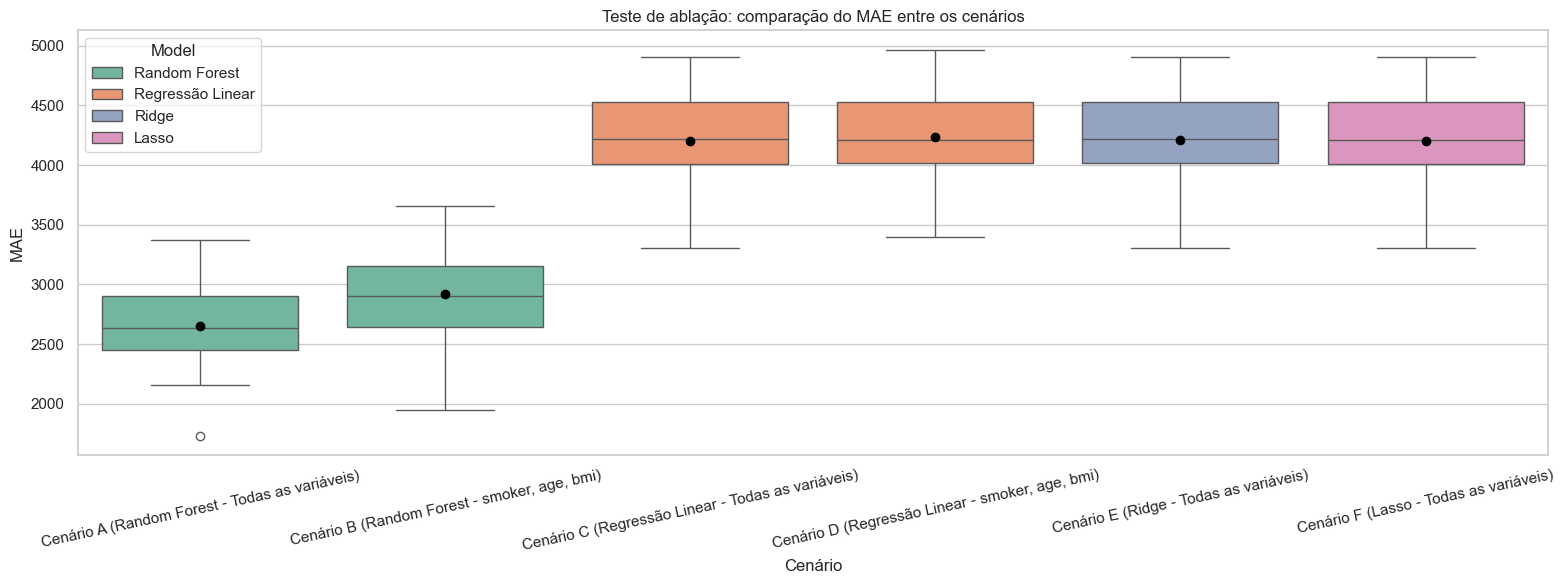

In [13]:
plt.figure(figsize=(16, 6))
ax = sns.boxplot(
    data=split_results_ablation,
    x="Scenario",
    y="MAE",
    hue="Model",
    dodge=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 6,
    },
)
ax.set_title("Teste de ablação: comparação do MAE entre os cenários")
ax.set_xlabel("Cenário")
ax.set_ylabel("MAE")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()


## 9. Regularização Lasso (Cenário F)

O Lasso introduz penalização `L1`, podendo reduzir alguns coeficientes exatamente para zero. Isso permite interpretar a regularização também como um mecanismo automático de seleção de atributos.


In [14]:
def extract_lasso_coefficients(df: pd.DataFrame) -> pd.DataFrame:
    """Treina o Lasso e devolve os coeficientes finais."""
    numeric_features, categorical_features = split_features_by_type(FULL_FEATURES)
    X = df[FULL_FEATURES].copy()
    y = df[TARGET].copy()

    lasso_pipeline = build_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        model_type="lasso",
    )
    lasso_pipeline.fit(X, y)

    preprocessor = lasso_pipeline.named_steps["preprocessor"]
    model = lasso_pipeline.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    cleaned_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

    coef_df = pd.DataFrame(
        {
            "Feature": cleaned_names,
            "Coefficient": model.coef_,
            "AbsCoefficient": np.abs(model.coef_),
        }
    ).sort_values("AbsCoefficient", ascending=False).reset_index(drop=True)

    print(f"Melhor alpha encontrado pelo LassoCV: {model.alpha_:.6f}")
    return coef_df


lasso_coef_df = extract_lasso_coefficients(df)
display(lasso_coef_df)


Melhor alpha encontrado pelo LassoCV: 10.000000


,Feature,Coefficient,AbsCoefficient
0,smoker_no,"-23,778.9979","23,778.9979"
1,age,"3,600.1039","3,600.1039"
2,bmi,"2,046.4956","2,046.4956"
3,region_northeast,815.4943,815.4943
4,children,563.5783,563.5783
5,region_northwest,461.8899,461.8899
6,region_southeast,-124.7855,124.7855
7,sex_female,86.1908,86.1908
8,region_southwest,-58.1917,58.1917
9,sex_male,-0.0000,0.0000


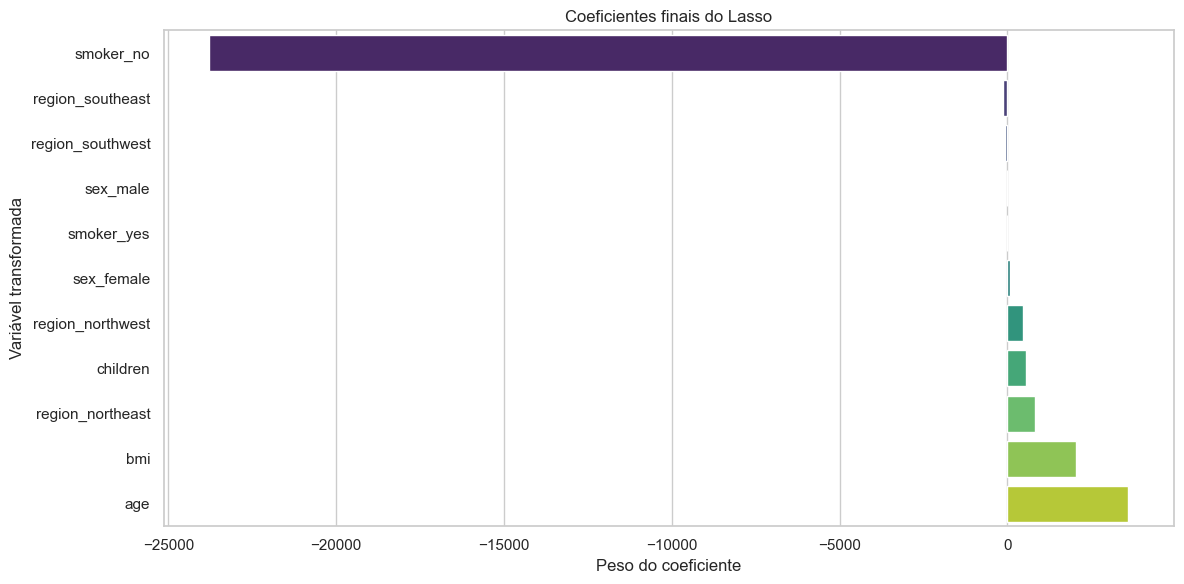

Variáveis zeradas pelo Lasso: ['sex_male', 'smoker_yes']


In [15]:
plt.figure(figsize=(12, 6))
plot_df = lasso_coef_df.sort_values("Coefficient")
ax = sns.barplot(
    data=plot_df,
    x="Coefficient",
    y="Feature",
    palette="viridis",
)
ax.set_title("Coeficientes finais do Lasso")
ax.set_xlabel("Peso do coeficiente")
ax.set_ylabel("Variável transformada")
plt.tight_layout()
plt.show()

zeroed_features = lasso_coef_df.loc[np.isclose(lasso_coef_df["Coefficient"], 0.0), "Feature"].tolist()
print("Variáveis zeradas pelo Lasso:", zeroed_features)


## 10. Análise de Resíduos do Modelo Campeão

Assumindo o desempenho superior do **Random Forest com todas as variáveis (Cenário A)**, realizamos uma análise de resíduos em uma divisão final `train_test_split (80/20)`. O objetivo é verificar se os erros parecem ser ruído aleatório ou se ainda há padrões sistemáticos ignorados pelo modelo.


In [16]:
numeric_features_all, categorical_features_all = split_features_by_type(FULL_FEATURES)
X_full = df[FULL_FEATURES].copy()
y_full = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

rf_champion = build_pipeline(
    numeric_features=numeric_features_all,
    categorical_features=categorical_features_all,
    model_type="rf",
)
rf_champion.fit(X_train, y_train)

y_pred_test = rf_champion.predict(X_test)
residuals = y_test - y_pred_test

residual_analysis_df = X_test.copy()
residual_analysis_df["y_real"] = y_test.values
residual_analysis_df["y_pred"] = y_pred_test
residual_analysis_df["residual"] = residuals.values
residual_analysis_df["abs_residual"] = residual_analysis_df["residual"].abs()

display(pd.DataFrame([compute_metrics(y_test, y_pred_test)]))


,MAE,RMSE,R2
0,"2,541.6146","4,582.9726",0.8647


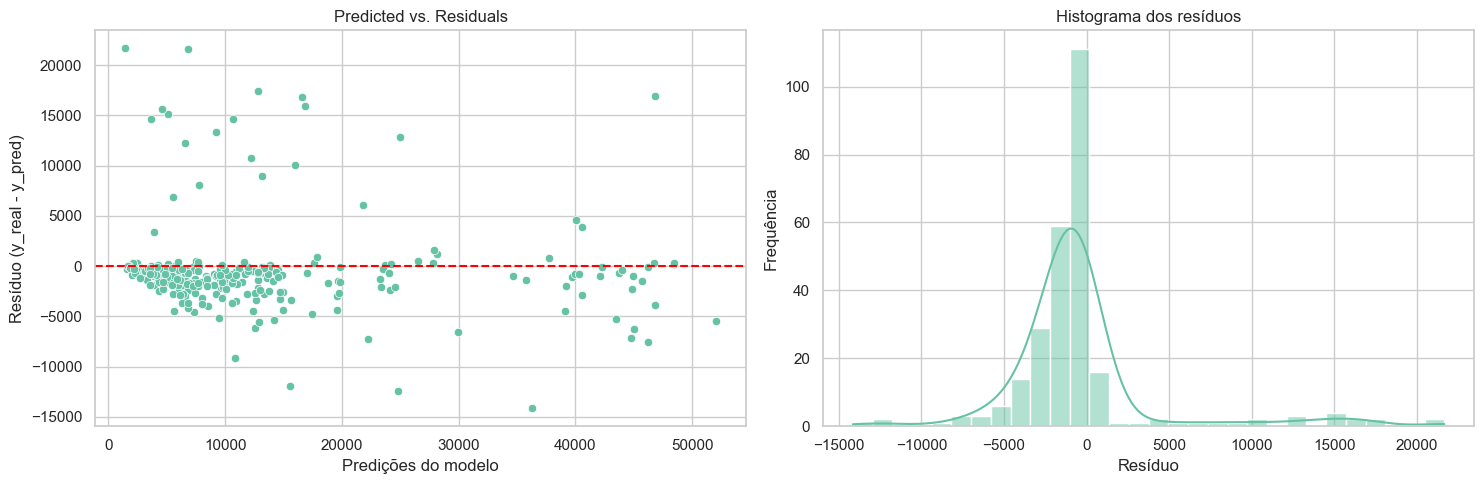

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=residual_analysis_df,
    x="y_pred",
    y="residual",
    ax=axes[0],
)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Predicted vs. Residuals")
axes[0].set_xlabel("Predições do modelo")
axes[0].set_ylabel("Resíduo (y_real - y_pred)")

sns.histplot(
    data=residual_analysis_df,
    x="residual",
    kde=True,
    bins=30,
    ax=axes[1],
)
axes[1].set_title("Histograma dos resíduos")
axes[1].set_xlabel("Resíduo")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()


## 11. Inspeção dos 5 Maiores Erros Absolutos

A tabela abaixo destaca os cinco pacientes em que o modelo campeão errou mais. Este diagnóstico ajuda a identificar padrões difíceis, como **não-fumantes com custos reais surpreendentemente elevados**, que podem sugerir fatores clínicos não observados no dataset.


In [18]:
top_5_outliers = residual_analysis_df.sort_values(
    "abs_residual",
    ascending=False,
).head(5)

display(
    top_5_outliers[
        [
            "age",
            "sex",
            "bmi",
            "children",
            "smoker",
            "region",
            "y_real",
            "y_pred",
            "residual",
            "abs_residual",
        ]
    ]
)


,age,sex,bmi,children,smoker,region,y_real,y_pred,residual,abs_residual
430,19,male,33.1000,0,no,southwest,"23,082.9553","1,414.3875","21,668.5679","21,668.5679"
806,40,female,41.4200,1,no,northwest,"28,476.7350","6,845.3945","21,631.3405","21,631.3405"
115,60,male,28.5950,0,no,northeast,"30,259.9956","12,836.2723","17,423.7232","17,423.7232"
543,54,female,47.4100,0,yes,southeast,"63,770.4280","46,843.8252","16,926.6028","16,926.6028"
599,52,female,37.5250,2,no,northwest,"33,471.9719","16,594.9673","16,877.0046","16,877.0046"


## 12. Conclusões Integradas

### Síntese metodológica

- O uso de `Pipeline` com imputação, `StandardScaler` e codificação categórica dentro de cada fold elimina o risco de *data leakage*.
- Os protocolos Hold-out, K-Fold e Repeated K-Fold não produzem estimativas idênticas, o que reforça a discussão metodológica inspirada em Tougui et al.
- O LOOCV foi mantido apenas para a Regressão Linear como prova de conceito, dada a sua natureza computacionalmente pesada e a limitação do `R²` por fold.

### Síntese comparativa

- A comparação entre **Random Forest** e **Regressão Linear** permite avaliar não apenas desempenho médio, mas também estabilidade via desvio padrão do `MAE` e do `RMSE`.
- O teste de ablação mostra se a remoção de atributos fracos afeta de forma semelhante modelos lineares e não lineares.
- O **Lasso (Cenário F)** fornece uma ponte entre interpretabilidade e seleção automática de atributos, enquanto o **Random Forest (Cenário A)** tende a servir como referência de melhor desempenho.

### Síntese diagnóstica

- A análise de resíduos ajuda a verificar se o erro do modelo campeão é predominantemente ruído ou se ainda existe estrutura sistemática ignorada.
- A inspeção dos maiores erros absolutos fornece evidência qualitativa importante para discutir limitações do dataset e possíveis fatores clínicos ausentes.
